In [2]:
import cv2
import time
from insightface.app import FaceAnalysis
from matplotlib import pyplot as plt

## Insightface 모델 로드

In [3]:
app = FaceAnalysis(
    providers=['CPUExecutionProvider']
)

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

## AdaFace 모델 로드

In [4]:
import os

print("현재 위치:")
print(os.getcwd())

print("\n현재 폴더 목록:")
for x in os.listdir("."):
    print(x)

현재 위치:
C:\Users\wonbin\Desktop\face-test\notebook

현재 폴더 목록:
.ipynb_checkpoints
adaface
adafaceTest.ipynb
insightface-detection.ipynb
insightface.ipynb
yolov8n.ipynb


In [5]:
import os
import sys

if not os.path.exists("./adaface"):
    from huggingface_hub import snapshot_download

    snapshot_download(
        repo_id="minchul/cvlface_adaface_ir50_webface4m",
        local_dir="./adaface"
    )
sys.path.append("./adaface")

In [6]:
from omegaconf import OmegaConf
from models import get_model

conf = OmegaConf.load(
    "./adaface/pretrained_model/model.yaml"
)

for root, dirs, files in os.walk("./adaface"):
    for file in files:
        if file.endswith(".pt") or file.endswith(".ckpt") or file.endswith(".pth"):
            print(os.path.join(root, file))

print(conf)
model = get_model(conf)

./adaface\pretrained_model\model.pt
{'input_size': [3, 112, 112], 'color_space': 'RGB', 'name': 'ir50', 'output_dim': 512, 'start_from': '', 'freeze': False, 'yaml_path': 'models/iresnet/configs/v1_ir50.yaml'}
Loaded iResNet model


In [7]:
import torch

state_dict = torch.load(
    "./adaface/pretrained_model/model.pt",
    map_location="cpu"
)

msg = model.load_state_dict(
    state_dict,
    strict=False
)

print(msg)

<All keys matched successfully>


### test.jpg 이미지 읽기

In [33]:
image_dir = "../images/similar"

image_paths = sorted([
    os.path.join(image_dir, file)
    for file in os.listdir(image_dir)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(image_paths)

['../images/similar\\embedding1.jpg', '../images/similar\\embedding2.jpg', '../images/similar\\embedding3.jpg', '../images/similar\\embedding4.jpg', '../images/similar\\embedding5.jpg', '../images/similar\\embedding6.jpg']


## 1단계 : Detection + Landmark만 수행

In [34]:
import cv2

all_faces = []

for image_path in image_paths:

    img = cv2.imread(image_path)

    if img is None:
        print(f"Cannot read image: {image_path}")
        continue

    faces = app.get(img)

    if len(faces) == 0:
        print(f"No face detected: {image_path}")
        continue

    face = faces[0]

    print(f"\n=== {image_path} ===")

    print("bbox")
    print(face.bbox.astype(int))

    print("landmark")
    print(face.kps)

    all_faces.append({
        "image_path": image_path,
        "img": img,
        "face": face
    })


=== ../images/similar\embedding1.jpg ===
bbox
[238 102 425 380]
landmark
[[278.8575  215.44424]
 [368.7001  209.4305 ]
 [321.44357 266.92337]
 [289.5798  307.69724]
 [371.08606 302.48663]]

=== ../images/similar\embedding2.jpg ===
bbox
[183  98 365 332]
landmark
[[222.23183 203.14758]
 [299.23935 186.83548]
 [262.6099  246.79533]
 [250.3374  288.0733 ]
 [307.42755 275.10403]]

=== ../images/similar\embedding3.jpg ===
bbox
[148  62 444 454]
landmark
[[224.27942 223.3431 ]
 [361.81268 223.68323]
 [292.4802  320.4438 ]
 [247.21234 377.25412]
 [340.6417  377.49185]]

=== ../images/similar\embedding4.jpg ===
bbox
[232  90 420 353]
landmark
[[279.37396 198.87898]
 [369.80264 195.33789]
 [324.64606 246.58308]
 [288.11618 289.2682 ]
 [365.57217 286.2073 ]]

=== ../images/similar\embedding5.jpg ===
bbox
[ 84  31 187 172]
landmark
[[106.77403   90.4306  ]
 [154.45116   86.174545]
 [129.31868  117.194885]
 [115.94651  141.4292  ]
 [153.88087  137.66254 ]]

=== ../images/similar\embedding6.jpg ==

## 2단계 : Alignment 이미지 추출

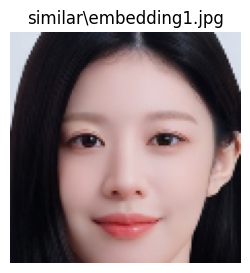

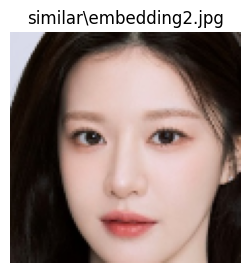

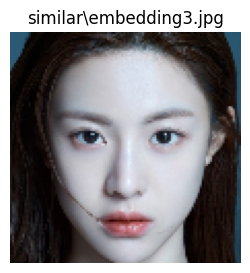

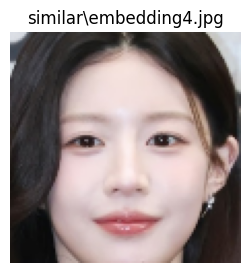

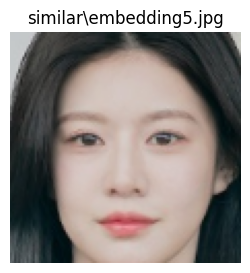

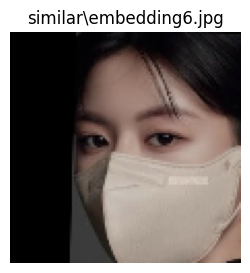

In [35]:
from insightface.utils import face_align
import matplotlib.pyplot as plt

aligned_faces = []

for image_path in image_paths:

    img = cv2.imread(image_path)

    faces = app.get(img)

    if len(faces) == 0:
        print(f"No face detected: {image_path}")
        continue

    face = faces[0]

    aligned = face_align.norm_crop(
        img,
        landmark=face.kps
    )

    aligned_faces.append(aligned)

    plt.figure(figsize=(3,3))
    plt.imshow(
        cv2.cvtColor(
            aligned,
            cv2.COLOR_BGR2RGB
        )
    )
    plt.title(image_path.split("/")[-1])
    plt.axis("off")
    plt.show()

## 3단계: ArcFace 임베딩

In [36]:
import numpy as np
rec_model = app.models["recognition"]

arc_embeddings = []

for aligned in aligned_faces:

    emb = rec_model.get_feat(aligned)

    emb = emb.squeeze()

    emb = emb / np.linalg.norm(emb)

    arc_embeddings.append(emb)

    print(
        emb.shape,
        np.linalg.norm(emb)
    )

(512,) 1.0
(512,) 1.0
(512,) 0.99999994
(512,) 1.0
(512,) 1.0
(512,) 1.0


## 4단계 : AdaFace 임베딩

In [37]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2

ada_embeddings = []

for aligned in aligned_faces:

    aligned_rgb = cv2.cvtColor(
        aligned,
        cv2.COLOR_BGR2RGB
    )

    img_tensor = torch.tensor(
        aligned_rgb.astype(np.float32) / 255.0
    )

    img_tensor = (img_tensor - 0.5) / 0.5

    img_tensor = img_tensor.permute(2, 0, 1)
    img_tensor = img_tensor.unsqueeze(0)

    with torch.no_grad():
        embedding = F.normalize(
            model(img_tensor),
            p=2,
            dim=1
        )

    embedding = embedding.squeeze().cpu().numpy()

    ada_embeddings.append(embedding)

    print(
        embedding.shape,
        np.linalg.norm(embedding)
    )

(512,) 0.99999994
(512,) 1.0
(512,) 1.0
(512,) 1.0
(512,) 1.0000001
(512,) 0.99999994


## 5단계 : ArcFace 임베딩 결과 상호 비교

In [38]:
for i in range(len(arc_embeddings)):
    for j in range(i+1, len(arc_embeddings)):

        score = np.dot(
            arc_embeddings[i],
            arc_embeddings[j]
        )

        print(
            f"{os.path.basename(image_paths[i])}"
            f" vs "
            f"{os.path.basename(image_paths[j])}"
            f" : {score:.4f}"
        )

embedding1.jpg vs embedding2.jpg : 0.6866
embedding1.jpg vs embedding3.jpg : 0.4167
embedding1.jpg vs embedding4.jpg : 0.7451
embedding1.jpg vs embedding5.jpg : 0.6929
embedding1.jpg vs embedding6.jpg : 0.3956
embedding2.jpg vs embedding3.jpg : 0.4389
embedding2.jpg vs embedding4.jpg : 0.6057
embedding2.jpg vs embedding5.jpg : 0.7096
embedding2.jpg vs embedding6.jpg : 0.3365
embedding3.jpg vs embedding4.jpg : 0.4121
embedding3.jpg vs embedding5.jpg : 0.4165
embedding3.jpg vs embedding6.jpg : 0.4120
embedding4.jpg vs embedding5.jpg : 0.6517
embedding4.jpg vs embedding6.jpg : 0.3702
embedding5.jpg vs embedding6.jpg : 0.4057


## 6단계 : AdaFace 임베딩 결과 상호 비교

In [39]:
for i in range(len(ada_embeddings)):
    for j in range(i+1, len(ada_embeddings)):

        score = np.dot(
            ada_embeddings[i],
            ada_embeddings[j]
        )

        print(
            f"{os.path.basename(image_paths[i])}"
            f" vs "
            f"{os.path.basename(image_paths[j])}"
            f" : {score:.4f}"
        )

embedding1.jpg vs embedding2.jpg : 0.6430
embedding1.jpg vs embedding3.jpg : 0.4339
embedding1.jpg vs embedding4.jpg : 0.7573
embedding1.jpg vs embedding5.jpg : 0.6605
embedding1.jpg vs embedding6.jpg : 0.4417
embedding2.jpg vs embedding3.jpg : 0.5074
embedding2.jpg vs embedding4.jpg : 0.6307
embedding2.jpg vs embedding5.jpg : 0.7024
embedding2.jpg vs embedding6.jpg : 0.4001
embedding3.jpg vs embedding4.jpg : 0.4952
embedding3.jpg vs embedding5.jpg : 0.4524
embedding3.jpg vs embedding6.jpg : 0.4846
embedding4.jpg vs embedding5.jpg : 0.6956
embedding4.jpg vs embedding6.jpg : 0.4168
embedding5.jpg vs embedding6.jpg : 0.4961
